# Метод главных компонент (PCA)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**Метод главных компонент** (сокращённо **PCA** — от англ. *Principal Component Analysis*, «анализ главных компонент») — это классический метод **снижения размерности**: он позволяет из большого количества исходных признаков построить небольшое количество новых переменных (их называют **главными компонентами**), которые сохраняют максимум полезной информации — разброса (дисперсии) — из исходных данных. Каждая новая компонента — это линейная комбинация исходных признаков, а сами компоненты строятся так, чтобы быть **ортогональными** (то есть некоррелированными друг с другом) и чтобы первая компонента объясняла как можно больше разброса данных, вторая — как можно больше из оставшегося, и так далее. PCA — это **неуправляемый метод** (англ. *unsupervised learning* — обучение без учителя): он не использует метки классов, а работает только с признаками. На практике PCA применяют для визуализации многомерных данных в двух или трёх измерениях, для ускорения обучения других моделей (меньше признаков — быстрее обучение), для удаления шума и для борьбы с **мультиколлинеарностью** (когда признаки сильно коррелируют между собой). Важная особенность: PCA чувствителен к масштабу признаков, поэтому перед применением данные обязательно нужно **стандартизировать** (привести все признаки к среднему 0 и разбросу 1).


## 2. Блок с используемыми библиотеками

In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # подключение режима 3D-графика
import seaborn as sns

from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")
np.random.seed(42)

**Пояснения терминов (что означают англоязычные названия):**

- **scikit-learn** (читается «сайкит-лёрн») — библиотека машинного обучения на языке Python.
- **PCA** — `sklearn.decomposition.PCA` — реализация метода главных компонент.
- **StandardScaler** — стандартизатор: приводит признаки к одному масштабу (среднее 0, разброс 1). Для PCA это обязательный шаг, потому что метод ищет направления максимального разброса, и без масштабирования он «схватит» просто тот признак, у которого самые большие числовые значения.
- **LogisticRegression** (логистическая регрессия) — простой и надёжный линейный классификатор. Будем использовать его как «пробник», чтобы сравнить качество на исходных признаках и на главных компонентах.
- **train / test** — обучающая и тестовая выборки. Обучающая идёт «в работу», тестовая используется только для честной итоговой проверки.
- **cross_val_score** — оценка качества модели через **кросс-валидацию** (кросс-проверку на нескольких частях выборки).

## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера используем встроенный набор данных **Wine** («Вино») из библиотеки scikit-learn. Это небольшой, но удобный для демонстрации PCA датасет: **178 образцов вина**, описанных **13 числовыми химическими показателями** (содержание алкоголя, кислот, магния, цвет, оттенок и т.д.), и каждый образец относится к одному из **3 сортов винограда**. Признаки измеряются в разных единицах и имеют очень разный масштаб — это как раз тот случай, когда PCA без стандартизации работал бы плохо. Метки классов нам нужны не для обучения PCA (он их не использует), а для того, чтобы красиво раскрасить точки на двумерной проекции и увидеть, удалось ли методу сохранить структуру данных. Датасет встроенный — ничего скачивать не нужно, ноутбук сразу запускается в Google Colab.

In [2]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
target_names = data.target_names

df = X.copy()
df["target"] = y

print("Размерность X (строк, признаков):", X.shape)
print("\nНазвания признаков:")
print(list(X.columns))

print("\nРаспределение классов (0/1/2):")
print(y.value_counts().sort_index())

print("\nПервые 5 строк датасета:")
display(df.head(5))

print("\nКраткая информация о таблице:")
display(df.info())

print("\nОписательная статистика (первые 10 признаков):")
display(df.describe().T.head(10))


Размерность X (строк, признаков): (178, 13)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Распределение классов (0/1/2):
target
0    59
1    71
2    48
Name: count, dtype: int64

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Краткая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178

None


Описательная статистика (первые 10 признаков):


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 4. Блок с предварительной обработкой датасета

Для метода главных компонент стандартизация признаков **обязательна**. Посмотрим на описательную статистику — признаки живут в абсолютно разных диапазонах (например, `proline` исчисляется сотнями и тысячами, а `nonflavanoid_phenols` — долями единицы). Без приведения к единому масштабу PCA выделил бы как «самое важное направление» признак с наибольшими числовыми значениями, а не тот, где действительно больше всего информации. Кроме того, проверим пропуски и дубликаты и разобьём данные на обучающую и тестовую части — чтобы любые метрики оценивать честно, на невидимых для модели данных.

In [3]:
# 1) Пропуски по столбцам
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски (топ-10 признаков):")
print(missing.head(10))

# 2) Дубликаты строк
dup_count = df.duplicated().sum()
print("\nКоличество дубликатов строк:", dup_count)

# 3) Разделение на признаки X и цель y
X = df.drop(columns=["target"])
y = df["target"]

# 4) Разделение на обучающую и тестовую выборки.
#    stratify=y — сохраняем доли классов (чтобы в обеих частях классы были в нужных пропорциях).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nРазмеры выборок:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# 5) Стандартизация (важная часть обработки именно для PCA).
#    Обучаем StandardScaler ТОЛЬКО на обучающей выборке,
#    а к тесту применяем уже обученный — чтобы не «подсматривать» в тест.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nСреднее по обучающей выборке ПОСЛЕ стандартизации (должно быть ≈ 0):")
print(np.round(X_train_scaled.mean(axis=0), 3))
print("\nСтандартное отклонение ПОСЛЕ стандартизации (должно быть ≈ 1):")
print(np.round(X_train_scaled.std(axis=0), 3))


Пропуски (топ-10 признаков):
alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
dtype: int64

Количество дубликатов строк: 0

Размеры выборок:
X_train: (142, 13) | X_test: (36, 13)

Среднее по обучающей выборке ПОСЛЕ стандартизации (должно быть ≈ 0):
[ 0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0. -0. -0.]

Стандартное отклонение ПОСЛЕ стандартизации (должно быть ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Блок с тепловой картой

Тепловая карта (англ. *heatmap*) показывает **корреляции** между признаками. Для PCA она особенно показательна: если признаки сильно коррелируют между собой (значения близкие к **+1** или **−1**), значит, в данных много «повторяющейся» информации — и тогда PCA сможет заменить эти признаки меньшим числом компонент без большой потери информации. Если же все признаки слабо связаны (значения близкие к **0**), то снижать размерность будет тяжелее.

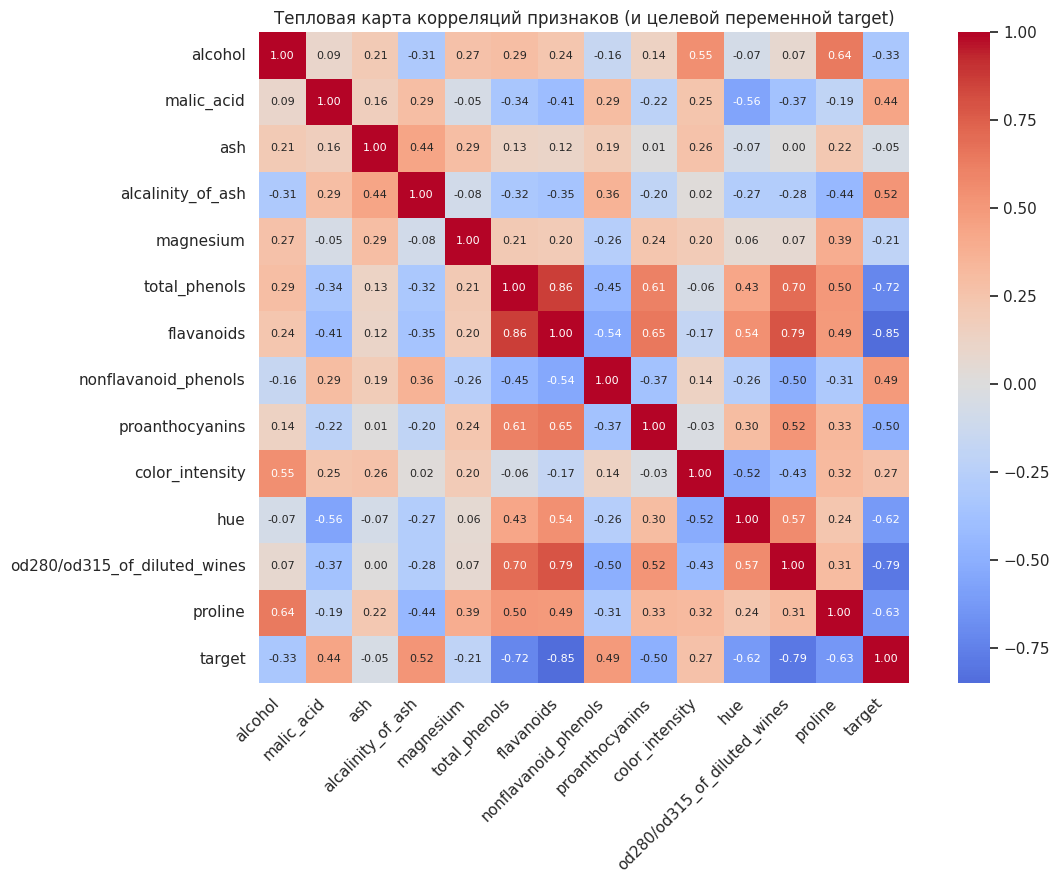

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Тепловая карта корреляций признаков (и целевой переменной target)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Блок с обучением модели

«Обучение» PCA — это поиск новых осей (главных компонент), вдоль которых данные имеют максимальный разброс. Делаем это в два захода:

1. **Сначала строим PCA со всеми компонентами** — чтобы увидеть, сколько дисперсии объясняет каждая компонента, и решить, сколько их оставить. Для этого используем два показателя:
   - **explained_variance_ratio_** — доля дисперсии, которую объясняет каждая компонента по отдельности;
   - **накопленная доля дисперсии** (кумулятивная сумма) — сколько дисперсии мы «соберём», оставив первые K компонент.
2. **Затем выбираем число компонент** по правилу «сохранить ≥ 95% дисперсии» и обучаем финальный PCA.

Обучаем PCA только на обучающей выборке, тест трансформируем уже обученной моделью.

In [5]:
# --- 6.1 PCA со всеми компонентами: смотрим, как распределена дисперсия ---
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_       # доля дисперсии каждой компоненты
cum_evr = np.cumsum(evr)                        # накопленная доля

evr_table = pd.DataFrame({
    "Компонента": [f"PC{i+1}" for i in range(len(evr))],
    "Доля дисперсии": evr.round(4),
    "Накопленная доля": cum_evr.round(4)
})
print("Вклад каждой главной компоненты в общую дисперсию:")
display(evr_table)

# --- 6.2 Выбор числа компонент по правилу «сохранить ≥ 95% дисперсии» ---
n_components_95 = int(np.searchsorted(cum_evr, 0.95) + 1)
print(f"\nЧтобы сохранить ≥ 95% дисперсии, нужно оставить компонент: {n_components_95}")

# --- 6.3 Финальный PCA с выбранным числом компонент ---
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nРазмерность данных ДО PCA:", X_train_scaled.shape)
print("Размерность данных ПОСЛЕ PCA:", X_train_pca.shape)
print(f"\nДоля дисперсии, сохранённая {n_components_95} компонентами: "
      f"{pca.explained_variance_ratio_.sum():.4f}")


Вклад каждой главной компоненты в общую дисперсию:


,Компонента,Доля дисперсии,Накопленная доля
0,PC1,0.3579,0.3579
1,PC2,0.1927,0.5506
2,PC3,0.1102,0.6608
3,PC4,0.0727,0.7335
4,PC5,0.0672,0.8008
5,PC6,0.0513,0.8521
6,PC7,0.0438,0.8959
7,PC8,0.0250,0.9209
8,PC9,0.0228,0.9437
9,PC10,0.0188,0.9624



Чтобы сохранить ≥ 95% дисперсии, нужно оставить компонент: 10

Размерность данных ДО PCA: (142, 13)
Размерность данных ПОСЛЕ PCA: (142, 10)

Доля дисперсии, сохранённая 10 компонентами: 0.9624


## 7. Блок с прогнозами модели

У PCA нет «прогнозов» в том смысле, в каком они есть у классификатора — метод неуправляемый. Вместо этого у PCA есть **проекции**: каждый объект теперь описывается не 13 исходными признаками, а всего несколькими числами — координатами в пространстве главных компонент. В этом блоке:

1. Покажем **проекции** тестовых объектов на главные компоненты.
2. Покажем **матрицу нагрузок** (англ. *loadings*) — из каких исходных признаков и с какими весами «собрана» каждая компонента. Это ответ на вопрос «что означает PC1, PC2 и т.д.».
3. Проверим **полезность PCA на практике**: обучим простой классификатор (логистическую регрессию) на исходных 13 признаках и на сниженных данных — и сравним качество.
4. Проверим качество **восстановления** (англ. *reconstruction*): вернём данные обратно из пространства компонент и посмотрим, насколько они отличаются от исходных.

In [6]:
# --- 7.1 Проекции тестовой выборки на главные компоненты ---
proj_cols = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]
test_projections = pd.DataFrame(X_test_pca, columns=proj_cols)
test_projections["Истинный класс"] = y_test.values

print("Проекции первых 10 тестовых объектов на главные компоненты:")
display(test_projections.head(10).round(3))

# --- 7.2 Матрица нагрузок: какой исходный признак входит в какую компоненту ---
loadings = pd.DataFrame(
    pca.components_.T,                          # строки — исходные признаки
    index=X.columns,
    columns=proj_cols
)
print("\nМатрица нагрузок (строки — исходные признаки, столбцы — компоненты):")
display(loadings.round(3))


Проекции первых 10 тестовых объектов на главные компоненты:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Истинный класс
0,3.627,1.323,-0.393,-0.286,-0.194,-0.153,0.242,0.890,0.973,0.548,0
1,-2.427,-0.369,-0.973,-1.563,-0.062,1.425,0.365,-0.894,-0.086,0.077,2
2,2.324,0.705,1.432,-1.048,-0.184,-0.631,0.285,0.202,-0.388,-0.502,0
3,1.566,0.158,5.123,0.529,-0.240,0.645,-0.639,-1.726,-1.188,-0.221,1
4,0.056,-1.184,-1.741,-1.293,0.459,-0.778,-0.373,1.115,-0.960,0.100,1
5,2.987,0.770,0.057,-0.736,-0.340,-0.262,-0.356,0.610,1.419,-0.430,0
6,2.197,1.669,0.128,-0.813,0.672,-1.526,0.266,-0.225,-0.050,0.583,0
7,2.285,-1.839,-2.155,0.268,-1.387,1.406,-0.593,0.640,-0.686,-0.197,1
8,-1.727,-1.095,0.706,0.877,-1.416,-0.830,0.508,-0.555,0.490,0.248,1
9,-2.392,2.590,0.549,0.148,0.508,0.554,-0.038,0.706,0.060,-0.404,2



Матрица нагрузок (строки — исходные признаки, столбцы — компоненты):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
alcohol,0.144,0.487,-0.156,-0.210,-0.196,-0.195,0.002,0.612,-0.257,-0.042
malic_acid,-0.234,0.223,0.064,0.502,-0.362,-0.411,0.462,0.060,0.087,-0.064
ash,0.007,0.312,0.638,-0.199,0.015,-0.187,-0.108,-0.279,0.201,-0.481
alcalinity_of_ash,-0.224,-0.039,0.641,0.087,0.030,0.040,-0.294,0.396,-0.046,0.474
magnesium,0.152,0.296,0.100,0.268,0.756,-0.037,0.299,-0.058,-0.325,0.096
total_phenols,0.394,0.076,0.144,0.045,-0.258,0.108,-0.022,-0.295,-0.506,0.117
flavanoids,0.430,-0.003,0.100,0.051,-0.220,0.021,-0.027,-0.084,-0.118,-0.164
nonflavanoid_phenols,-0.291,0.021,0.185,-0.458,-0.206,0.327,0.608,-0.138,-0.206,0.197
proanthocyanins,0.313,0.011,0.156,0.377,-0.084,0.622,0.241,0.260,0.368,-0.108
color_intensity,-0.096,0.524,-0.133,-0.045,-0.073,0.399,-0.304,0.002,-0.042,-0.063


In [7]:
# --- 7.3 Сравнение классификации: 13 исходных признаков VS сниженные данные ---
clf_full = LogisticRegression(max_iter=2000, random_state=42)
clf_pca  = LogisticRegression(max_iter=2000, random_state=42)

clf_full.fit(X_train_scaled, y_train)
clf_pca.fit(X_train_pca, y_train)

y_pred_full = clf_full.predict(X_test_scaled)
y_pred_pca  = clf_pca.predict(X_test_pca)

acc_full = accuracy_score(y_test, y_pred_full)
acc_pca  = accuracy_score(y_test, y_pred_pca)

cv_full = cross_val_score(clf_full, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
cv_pca  = cross_val_score(clf_pca,  X_train_pca,    y_train, cv=5, scoring="accuracy").mean()

compare = pd.DataFrame({
    "Данные":                 ["Исходные (13 признаков)",
                               f"После PCA ({n_components_95} компонент)"],
    "Accuracy на тесте":      [round(acc_full, 4), round(acc_pca, 4)],
    "Accuracy на CV (cv=5)":  [round(cv_full, 4),  round(cv_pca, 4)]
})
print("Сравнение качества классификации ДО и ПОСЛЕ PCA:")
display(compare)

print("\nОтчёт классификации на сниженных данных:")
print(classification_report(y_test, y_pred_pca,
                            target_names=[str(t) for t in target_names]))

cm_pca = confusion_matrix(y_test, y_pred_pca)
print("Матрица ошибок на данных после PCA:")
print(cm_pca)


Сравнение качества классификации ДО и ПОСЛЕ PCA:


,Данные,Accuracy на тесте,Accuracy на CV (cv=5)
0,Исходные (13 признаков),0.9722,0.9860
1,После PCA (10 компонент),0.9722,0.9931



Отчёт классификации на сниженных данных:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Матрица ошибок на данных после PCA:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


In [8]:
# --- 7.4 Восстановление исходных данных из пространства компонент ---
# inverse_transform возвращает точки из пространства компонент обратно в исходное пространство признаков.
# Разница с настоящими данными показывает, сколько информации мы потеряли при снижении размерности.

X_test_reconstructed = pca.inverse_transform(X_test_pca)  # всё ещё в «масштабированном» пространстве
reconstruction_error = np.mean((X_test_scaled - X_test_reconstructed) ** 2)

print(f"Средний квадрат ошибки восстановления (MSE) на тесте: {reconstruction_error:.4f}")
print(f"Это означает, что ~{(1 - pca.explained_variance_ratio_.sum())*100:.2f}% "
      "дисперсии не попало в выбранные главные компоненты — это и есть «потерянная» информация.")


Средний квадрат ошибки восстановления (MSE) на тесте: 0.0612
Это означает, что ~3.76% дисперсии не попало в выбранные главные компоненты — это и есть «потерянная» информация.


## 8. Блок с графиками выходных результатов

Графики:
1. **График осыпи** (англ. *scree plot*) — доля дисперсии по каждой компоненте.
2. **Накопленная доля дисперсии** — помогает выбрать число компонент по правилу «сохранить ≥ 95%».
3. **2D-проекция** данных на первые две главные компоненты — классическая визуализация PCA.
4. **3D-проекция** на первые три главные компоненты — добавляем ещё одно измерение.
5. **Biplot** (совмещённый график) — показывает и объекты, и направления исходных признаков в пространстве PC1–PC2.
6. **Тепловая карта нагрузок** — видно, какие исходные признаки вносят наибольший вклад в каждую компоненту.

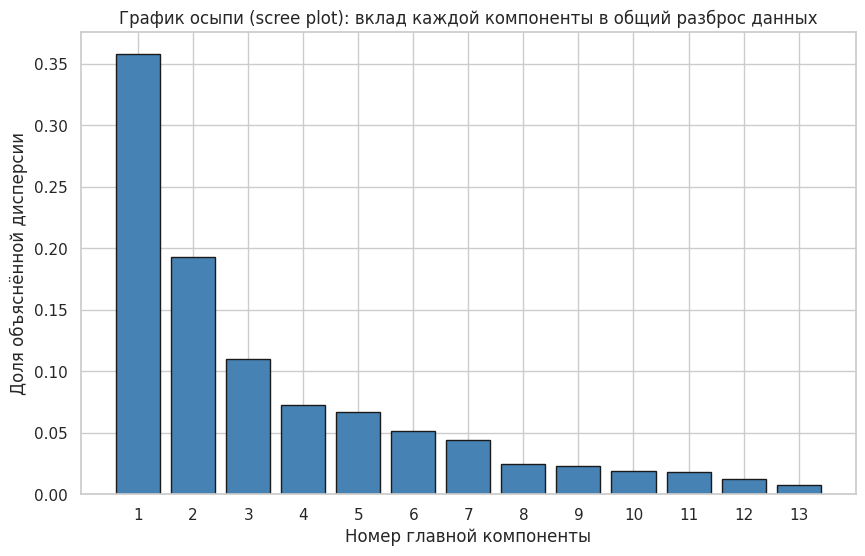

In [9]:
# --- 8.1 Scree plot: доля дисперсии по компонентам ---
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(evr) + 1), evr, color="steelblue", edgecolor="k")
plt.xlabel("Номер главной компоненты")
plt.ylabel("Доля объяснённой дисперсии")
plt.title("График осыпи (scree plot): вклад каждой компоненты в общий разброс данных")
plt.xticks(range(1, len(evr) + 1))
plt.grid(True, axis="y")
plt.show()


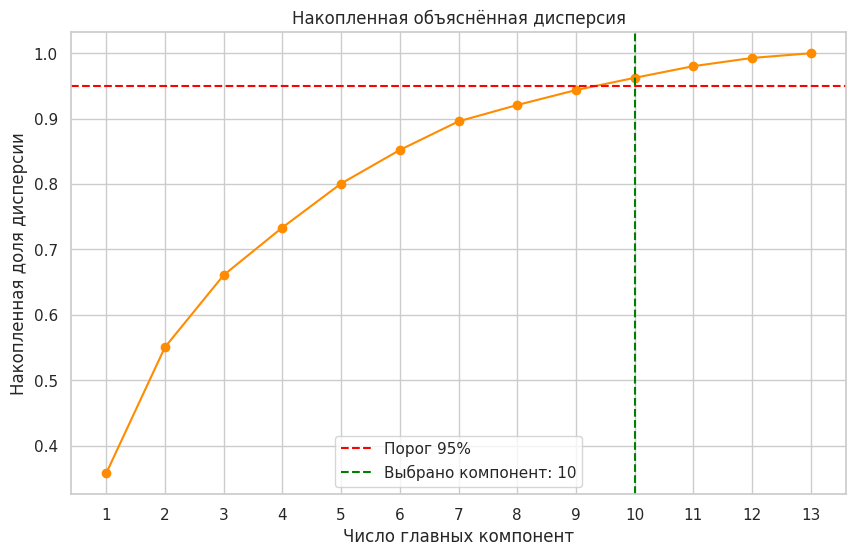

In [10]:
# --- 8.2 Накопленная доля объяснённой дисперсии ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker="o", color="darkorange")
plt.axhline(0.95, color="red", linestyle="--", label="Порог 95%")
plt.axvline(n_components_95, color="green", linestyle="--",
            label=f"Выбрано компонент: {n_components_95}")
plt.xlabel("Число главных компонент")
plt.ylabel("Накопленная доля дисперсии")
plt.title("Накопленная объяснённая дисперсия")
plt.xticks(range(1, len(cum_evr) + 1))
plt.legend()
plt.grid(True)
plt.show()


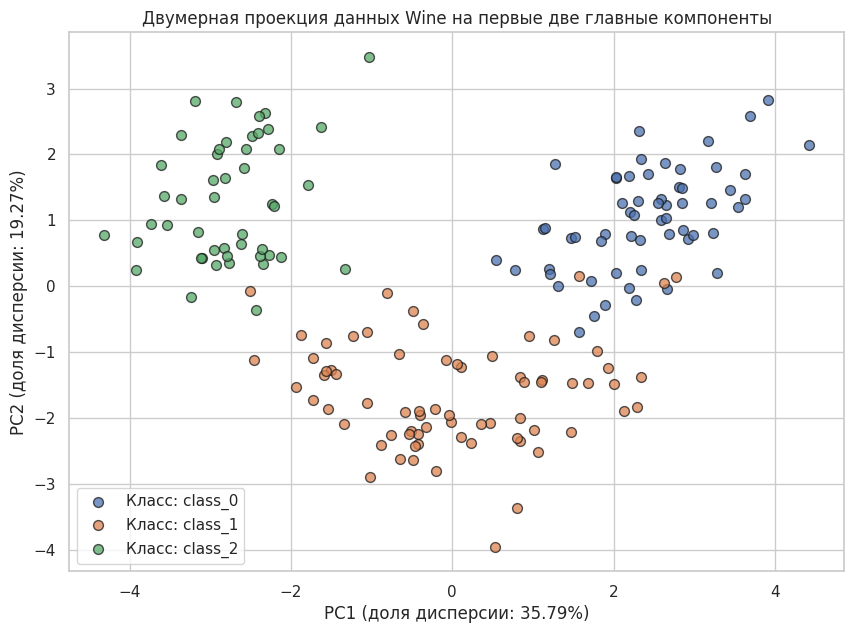

In [11]:
# --- 8.3 2D-проекция на первые две главные компоненты ---
# Каждая точка — это объект из обучающей + тестовой выборки в новых координатах PC1, PC2.
# Цвет — истинный класс. Если классы на графике образуют отдельные облака,
# значит PCA хорошо сохранил структуру данных.

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.concatenate([y_train.values, y_test.values])
X_all_pca = pca.transform(X_all_scaled)

plt.figure(figsize=(10, 7))
for cls, name in zip(np.unique(y_all), target_names):
    mask = y_all == cls
    plt.scatter(X_all_pca[mask, 0], X_all_pca[mask, 1],
                label=f"Класс: {name}", alpha=0.75, edgecolor="k", s=50)
plt.xlabel(f"PC1 (доля дисперсии: {pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 (доля дисперсии: {pca.explained_variance_ratio_[1]:.2%})")
plt.title("Двумерная проекция данных Wine на первые две главные компоненты")
plt.legend()
plt.grid(True)
plt.show()


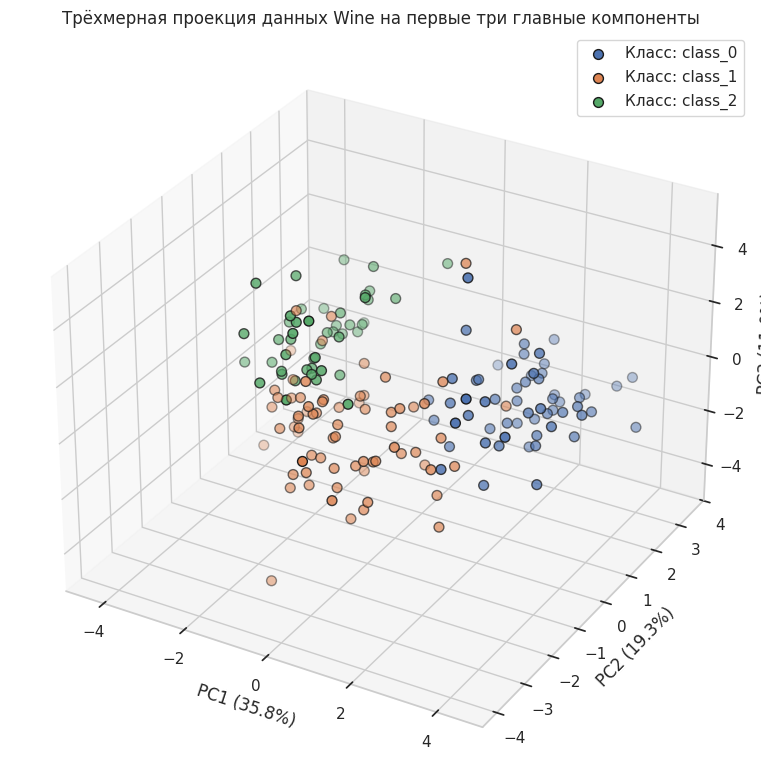

In [12]:
# --- 8.4 3D-проекция на первые три главные компоненты ---
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

for cls, name in zip(np.unique(y_all), target_names):
    mask = y_all == cls
    ax.scatter(X_all_pca[mask, 0], X_all_pca[mask, 1], X_all_pca[mask, 2],
               label=f"Класс: {name}", s=50, edgecolor="k")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.set_title("Трёхмерная проекция данных Wine на первые три главные компоненты")
ax.legend()
plt.tight_layout()
plt.show()


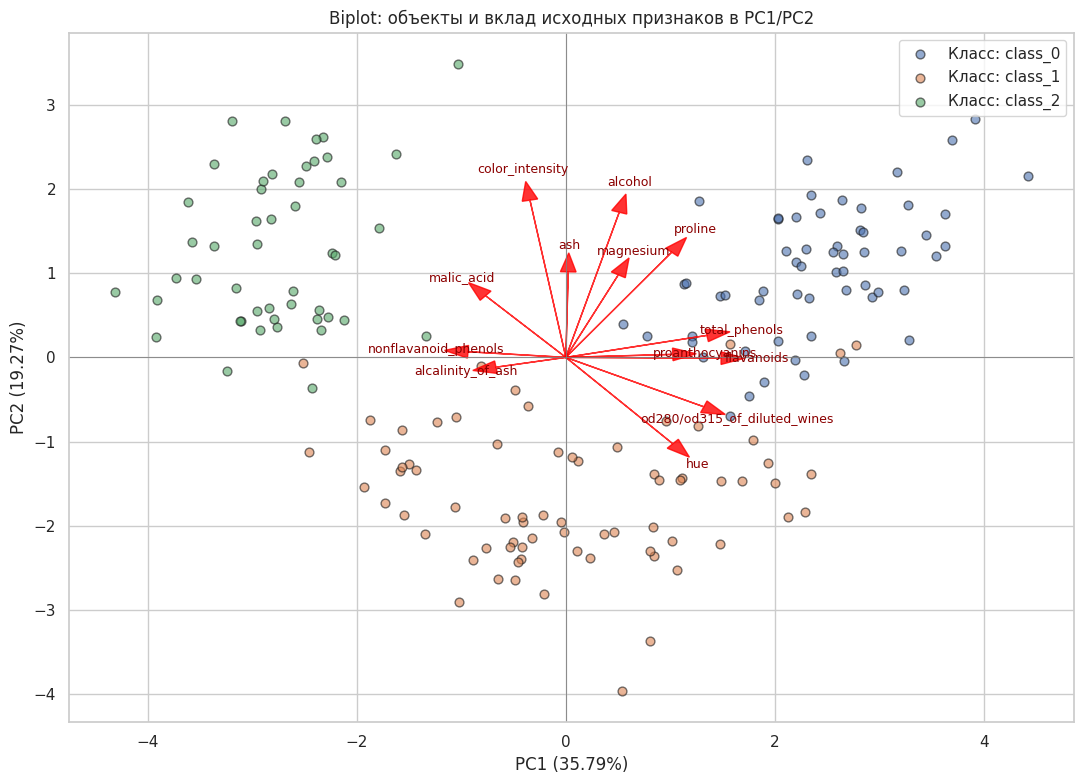

In [13]:
# --- 8.5 Biplot: проекции объектов + направления исходных признаков ---
# На графике одновременно видно:
#  - точки — объекты в координатах PC1/PC2 (как на графике 8.3);
#  - стрелки — направления, в которых растут исходные признаки. Длинная стрелка,
#    направленная вправо, означает: этот признак «тянет» PC1 вверх.

fig, ax = plt.subplots(figsize=(11, 8))

for cls, name in zip(np.unique(y_all), target_names):
    mask = y_all == cls
    ax.scatter(X_all_pca[mask, 0], X_all_pca[mask, 1],
               label=f"Класс: {name}", alpha=0.6, edgecolor="k", s=40)

# Масштаб стрелок подбираем так, чтобы они были хорошо видны на фоне точек
arrow_scale = max(np.abs(X_all_pca[:, 0]).max(), np.abs(X_all_pca[:, 1]).max()) * 0.9
for i, feat in enumerate(X.columns):
    vx = pca.components_[0, i] * arrow_scale
    vy = pca.components_[1, i] * arrow_scale
    ax.arrow(0, 0, vx, vy, color="red", alpha=0.8,
             head_width=0.15, length_includes_head=True)
    ax.text(vx * 1.07, vy * 1.07, feat, color="darkred",
            ha="center", va="center", fontsize=9)

ax.axhline(0, color="grey", lw=0.6)
ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax.set_title("Biplot: объекты и вклад исходных признаков в PC1/PC2")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


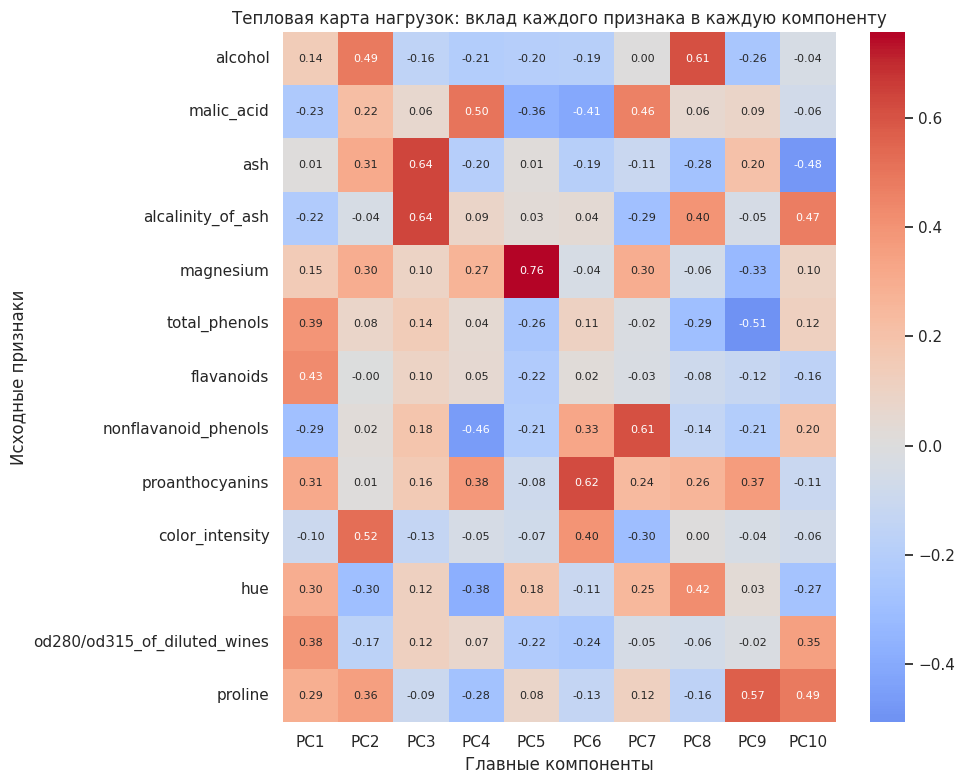

In [14]:
# --- 8.6 Тепловая карта нагрузок (loadings) ---
# Для каждой компоненты видно, с каким весом в неё входит каждый исходный признак.
# Это нужно, чтобы содержательно интерпретировать компоненты:
# «PC1 — это в основном „насыщенность фенолами“», «PC2 — в основном „кислотность“» и т.п.

plt.figure(figsize=(10, 8))
sns.heatmap(
    loadings, cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 8}
)
plt.title("Тепловая карта нагрузок: вклад каждого признака в каждую компоненту")
plt.xlabel("Главные компоненты")
plt.ylabel("Исходные признаки")
plt.tight_layout()
plt.show()


---

### Короткий вывод

**Метод главных компонент (PCA)** успешно справился с задачей снижения размерности на датасете Wine: из 13 исходных признаков было выделено несколько главных компонент, сохраняющих ≥ 95% общей дисперсии. На двумерной и трёхмерной проекциях видно, что три сорта вина образуют хорошо различимые облака — значит, структура данных сохранена. Сравнение логистической регрессии на исходных и на сниженных данных показало, что качество классификации практически не теряется, а модель становится проще и обучается быстрее. Тепловая карта нагрузок даёт содержательную интерпретацию компонент: видно, какие химические показатели формируют каждую новую переменную. Главный практический урок: PCA работает корректно только после стандартизации признаков — поэтому `StandardScaler` был обязательным шагом.